# LESSON 17 Библиотека pandas
# Анализ взаимосвязей. Описательная статистика. Сводные таблицы

## Примеры урока

**Применение функций**

In [ ]:
import pandas as pd
import numpy as np

**`.pipe()`**

In [11]:
data = pd.DataFrame(np.random.randint(1, 10, (5,3)), columns=list('XYZ'))
data

,X,Y,Z
0,8,5,4
1,9,9,1
2,2,8,5
3,7,1,5
4,3,2,2


In [13]:
def geom(df, n):
    df['geom'] = (df['X'] * df['Y'] * df['Z']) ** n
    return df

geom(data, 1/3)

,X,Y,Z,geom
0,8,5,4,5.428835
1,9,9,1,4.326749
2,2,8,5,4.308869
3,7,1,5,3.271066
4,3,2,2,2.289428


In [14]:
data.pipe(geom, n=1/3)

,X,Y,Z,geom
0,8,5,4,5.428835
1,9,9,1,4.326749
2,2,8,5,4.308869
3,7,1,5,3.271066
4,3,2,2,2.289428


In [15]:
def sum(df):
    df['sum'] = df['X'] + df['Y'] + df['Z']
    return df

In [16]:
sum(geom(data, 1/3))

,X,Y,Z,geom,sum
0,8,5,4,5.428835,17
1,9,9,1,4.326749,19
2,2,8,5,4.308869,15
3,7,1,5,3.271066,13
4,3,2,2,2.289428,7


In [17]:
data.pipe(sum).pipe(geom, 1/3)

,X,Y,Z,geom,sum
0,8,5,4,5.428835,17
1,9,9,1,4.326749,19
2,2,8,5,4.308869,15
3,7,1,5,3.271066,13
4,3,2,2,2.289428,7


In [18]:
(data.pipe(sum)
 .pipe(geom, 1/3))

,X,Y,Z,geom,sum
0,8,5,4,5.428835,17
1,9,9,1,4.326749,19
2,2,8,5,4.308869,15
3,7,1,5,3.271066,13
4,3,2,2,2.289428,7


In [19]:
def poly(n, XYZ=None, a=1, b=1, c=1):
    data['poly'] = a * data['X']**n + b * data['Y']**(n-1) + c * data['Z']**(n-2)
    return data

In [20]:
data.pipe((poly, 'XYZ'), 3, a=3, b=4, c=2)

,X,Y,Z,geom,sum,poly
0,8,5,4,5.428835,17,1644
1,9,9,1,4.326749,19,2513
2,2,8,5,4.308869,15,290
3,7,1,5,3.271066,13,1043
4,3,2,2,2.289428,7,101


In [21]:
(data.pipe(sum)
 .pipe(geom, 1/3)
 .pipe((poly, 'XYZ'), 3, a=3, b=4, c=2))

,X,Y,Z,geom,sum,poly
0,8,5,4,5.428835,17,1644
1,9,9,1,4.326749,19,2513
2,2,8,5,4.308869,15,290
3,7,1,5,3.271066,13,1043
4,3,2,2,2.289428,7,101


**Метод `.apply()`**

In [22]:
df = pd.DataFrame(np.random.randint(1, 10, (5,5)), index=list('abcde'), columns=['col_' + str(i) for i in range(5)])
df

,col_0,col_1,col_2,col_3,col_4
a,9,4,4,7,2
b,3,3,6,3,5
c,4,3,8,3,6
d,7,7,2,3,4
e,7,2,3,7,7


In [25]:
df.mean()

col_0    6.0
col_1    3.8
col_2    4.6
col_3    4.6
col_4    4.8
dtype: float64

In [26]:
df.mean(axis=1)

a    5.2
b    4.0
c    4.8
d    4.6
e    5.2
dtype: float64

In [27]:
df.apply(np.mean)

col_0    6.0
col_1    3.8
col_2    4.6
col_3    4.6
col_4    4.8
dtype: float64

In [28]:
df.apply(np.mean, axis=1)

a    5.2
b    4.0
c    4.8
d    4.6
e    5.2
dtype: float64

In [29]:
df.apply(lambda x: np.sum(x) / len(x), axis=1)

a    5.2
b    4.0
c    4.8
d    4.6
e    5.2
dtype: float64

In [30]:
df.apply(np.sqrt)

,col_0,col_1,col_2,col_3,col_4
a,3.000000,2.000000,2.000000,2.645751,1.414214
b,1.732051,1.732051,2.449490,1.732051,2.236068
c,2.000000,1.732051,2.828427,1.732051,2.449490
d,2.645751,2.645751,1.414214,1.732051,2.000000
e,2.645751,1.414214,1.732051,2.645751,2.645751


In [31]:
df.apply('mean', axis=1)

a    5.2
b    4.0
c    4.8
d    4.6
e    5.2
dtype: float64

In [32]:
df.apply(lambda x: [np.mean(x), np.max(x)], axis=1)

a    [5.2, 9]
b    [4.0, 6]
c    [4.8, 8]
d    [4.6, 7]
e    [5.2, 7]
dtype: object

In [33]:
df.apply(lambda x: [np.mean(x), np.max(x)], axis=1, result_type='expand')

,0,1
a,5.2,9.0
b,4.0,6.0
c,4.8,8.0
d,4.6,7.0
e,5.2,7.0


In [35]:
df.apply(lambda x: pd.Series([np.mean(x), np.max(x)], index=['mean', 'max']), axis=1)

,mean,max
a,5.2,9.0
b,4.0,6.0
c,4.8,8.0
d,4.6,7.0
e,5.2,7.0


In [37]:
data = pd.DataFrame(np.random.randint(100, 300, (2000, 3)), index=pd.date_range('16/4/2026', periods=2000), columns=list('abc'))
data

,a,b,c
2026-04-16,165,125,284
2026-04-17,296,229,155
2026-04-18,289,133,155
2026-04-19,154,119,149
2026-04-20,252,183,252
...,...,...,...
2031-10-02,278,220,149
2031-10-03,214,135,253
2031-10-04,132,222,199
2031-10-05,167,172,235


In [38]:
data.apply(lambda x: pd.Series([x.max(), x.min()], index=['max', 'min']))

,a,b,c
max,299,299,299
min,100,100,100


In [39]:
data.apply(lambda x: pd.Series([x.idxmax(), x.idxmin()], index=['max', 'min']))

,a,b,c
max,2026-11-22,2026-08-26,2027-05-06
min,2026-06-29,2026-09-03,2028-02-08


**Метод `.agg()`**

In [40]:
df = pd.DataFrame(np.arange(12).reshape(4, 3), index=list('abcd'), columns=list('XYZ'))
df

,X,Y,Z
a,0,1,2
b,3,4,5
c,6,7,8
d,9,10,11


In [45]:
df.agg(np.mean)

C:\Users\master\AppData\Local\Temp\ipykernel_14544\1193103369.py:1: FutureWarning: The provided callable <function mean at 0x0000019E683EF560> is currently using DataFrame.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.agg(np.mean)


X    4.5
Y    5.5
Z    6.5
dtype: float64

In [44]:
df.agg('mean')

X    4.5
Y    5.5
Z    6.5
dtype: float64

In [46]:
df.loc['d'].mean()

np.float64(10.0)

In [48]:
df.agg(['sum', np.mean, 'min'])

C:\Users\master\AppData\Local\Temp\ipykernel_14544\98871770.py:1: FutureWarning: The provided callable <function mean at 0x0000019E683EF560> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df.agg(['sum', np.mean, 'min'])


,X,Y,Z
sum,18.0,22.0,26.0
mean,4.5,5.5,6.5
min,0.0,1.0,2.0


In [49]:
df.agg(['sum', lambda x: (x**2).sum()])

,X,Y,Z
sum,18,22,26
<lambda>,126,166,214


In [50]:
df.agg(['sum', lambda x: (x**2).sum(), lambda x: x.mean()])

,X,Y,Z
sum,18.0,22.0,26.0
<lambda>,126.0,166.0,214.0
<lambda>,4.5,5.5,6.5


In [52]:
def sqr_x(x):
    return (x**2).sum()

def mean_x(x):
    return x.mean()

df.agg(['sum', sqr_x, mean_x])

,X,Y,Z
sum,18.0,22.0,26.0
sqr_x,126.0,166.0,214.0
mean_x,4.5,5.5,6.5


In [54]:
df.agg({'X': 'sum', 
        'Y': sqr_x, 
        'Z': lambda x: (1/x).sum()})

X     18.000000
Y    166.000000
Z      0.915909
dtype: float64

### 1. Описательная статистика

In [55]:
import pandas as pd
import numpy as np

In [57]:
# данные о файле:  https://www.kaggle.com/hesh97/titanicdataset-traincsv
titanic = pd.read_csv('titanic.csv', index_col=0)
titanic.head(3)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [58]:
#сортировка
titanic.sort_values(by = ['Pclass', 'Age'], ascending=[False, True])

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
165,0,3,"Panula, Master. Eino Viljami",male,1.00,4,1,3101295,39.6875,NaN,S
173,1,3,"Johnson, Miss. Eleanor Ileen",female,1.00,1,1,347742,11.1333,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
767,0,1,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6000,NaN,C
794,0,1,"Hoyt, Mr. William Fisher",male,NaN,0,0,PC 17600,30.6958,NaN,C
816,0,1,"Fry, Mr. Richard",male,NaN,0,0,112058,0.0000,B102,S


In [59]:
# полную информацию о датасете мы можем получить с помощью `info()`
titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [60]:
# посмотреть статистику по всему DataFrame
titanic.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [62]:
# `DataFrame` хранит не только числовые, но и категориальные признаки
titanic.describe(include=[object])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


In [63]:
# соотношение некоторых значений
titanic['Pclass'].value_counts(normalize=True)

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

In [64]:
# посмотреть количество уникальных значений
titanic['Sex'].unique()

array(['male', 'female'], dtype=object)

In [ ]:
# корреляцию между всеми столбцами датасета, если они численные
# Метод `.corr` вычисляет матрицу корреляций всех признаков из датафрейма
# Выбрать только числовые колонки
numeric_columns = titanic.select_dtypes(include=['number'])

# Посмотреть, какие колонки будут использоваться
print(numeric_columns.columns)

# Вычислить корреляцию
correlation_matrix = numeric_columns.corr()
correlation_matrix

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [68]:
# Методу `.corrwith` нужно подать еще один датафрейм в качестве аргумента, 
# и тогда он посчитает попарные корреляции между признаками
cols = ['Pclass','Age']
titanic[cols].corrwith(titanic['Survived'])

Pclass   -0.338481
Age      -0.077221
dtype: float64

In [69]:
# Посчитаем попарные корреляции между признаками Survived', 'Pclass' с помощью метода corr:
titanic[['Survived', 'Pclass']].corr()

,Survived,Pclass
Survived,1.000000,-0.338481
Pclass,-0.338481,1.000000


### 2. Операции со строками и столбцами

In [71]:
titanic.select_dtypes(include=['number']).mean()

Survived     0.383838
Pclass       2.308642
Age         29.699118
SibSp        0.523008
Parch        0.381594
Fare        32.204208
dtype: float64

In [72]:
titanic.T

PassengerId                      1    \
Survived                           0   
Pclass                             3   
Name         Braund, Mr. Owen Harris   
Sex                             male   
Age                             22.0   
SibSp                              1   
Parch                              0   
Ticket                     A/5 21171   
Fare                            7.25   
Cabin                            NaN   
Embarked                           S   

PassengerId                                                2    \
Survived                                                     1   
Pclass                                                       1   
Name         Cumings, Mrs. John Bradley (Florence Briggs Th...   
Sex                                                     female   
Age                                                       38.0   
SibSp                                                        1   
Parch                                                        0   
Ticket                                                PC 17599   
Fare                                                   71.2833   
Cabin                                                      C85   
Embarked                                                     C   

PassengerId                     3    \
Survived                          1   
Pclass                            3   
Name         Heikkinen, Miss. Laina   
Sex                          female   
Age                            26.0   
SibSp                             0   
Parch                             0   
Ticket             STON/O2. 3101282   
Fare                          7.925   
Cabin                           NaN   
Embarked                          S   

PassengerId                                           4    \
Survived                                                1   
Pclass                                                  1   
Name         Futrelle, Mrs. Jacques Heath (Lily May Peel)   
Sex                                                female   
Age                                                  35.0   
SibSp                                                   1   
Parch                                                   0   
Ticket                                             113803   
Fare                                                 53.1   
Cabin                                                C123   
Embarked                                                S   

PassengerId                       5                 6    \
Survived                            0                 0   
Pclass                              3                 3   
Name         Allen, Mr. William Henry  Moran, Mr. James   
Sex                              male              male   
Age                              35.0               NaN   
SibSp                               0                 0   
Parch                               0                 0   
Ticket                         373450            330877   
Fare                             8.05            8.4583   
Cabin                             NaN               NaN   
Embarked                            S                 Q   

PassengerId                      7                               8    \
Survived                           0                               0   
Pclass                             1                               3   
Name         McCarthy, Mr. Timothy J  Palsson, Master. Gosta Leonard   
Sex                             male                            male   
Age                             54.0                             2.0   
SibSp                              0                               3   
Parch                              0                               1   
Ticket                         17463                          349909   
Fare                         51.8625                          21.075   
Cabin                            E46                             NaN   
Embarked               

In [75]:
# Сначала выбрать числовые колонки, потом транспонировать
titanic_numeric = titanic.select_dtypes(include=['number'])
result = titanic_numeric.T.mean()
# print(result)
result

PassengerId
1       5.541667
2      18.713883
3       6.320833
4      15.183333
5       7.675000
         ...    
887     7.000000
888     8.500000
889     5.890000
890     9.666667
891     7.125000
Length: 891, dtype: float64

In [77]:
titanic_numeric = titanic.select_dtypes(include=['number'])
titanic_numeric.mean(axis=1)
#передать методу mean() параметр axis, указывающий, вдоль какой оси нужно считать

PassengerId
1       5.541667
2      18.713883
3       6.320833
4      15.183333
5       7.675000
         ...    
887     7.000000
888     8.500000
889     5.890000
890     9.666667
891     7.125000
Length: 891, dtype: float64

In [79]:
titanic_numeric = titanic.select_dtypes(include=['number'])
titanic_numeric.mean(axis='columns')
# второй способ

PassengerId
1       5.541667
2      18.713883
3       6.320833
4      15.183333
5       7.675000
         ...    
887     7.000000
888     8.500000
889     5.890000
890     9.666667
891     7.125000
Length: 891, dtype: float64

In [81]:
titanic_numeric = titanic.select_dtypes(include=['number'])
titanic_numeric.min() #минимальные значения

Survived    0.00
Pclass      1.00
Age         0.42
SibSp       0.00
Parch       0.00
Fare        0.00
dtype: float64

In [82]:
titanic_numeric = titanic.select_dtypes(include=['number'])
titanic_numeric.max() #максимальные

Survived      1.0000
Pclass        3.0000
Age          80.0000
SibSp         8.0000
Parch         6.0000
Fare        512.3292
dtype: float64

In [83]:
# сделать какой-то `sample` из исходного DataFrame
titanic.sample(frac=0.1)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
495,0,3,"Stanley, Mr. Edward Roland",male,21.00,0,0,A/4 45380,8.0500,NaN,S
177,0,3,"Lefebre, Master. Henry Forbes",male,NaN,3,1,4133,25.4667,NaN,S
676,0,3,"Edvardsson, Mr. Gustaf Hjalmar",male,18.00,0,0,349912,7.7750,NaN,S
804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
750,0,3,"Connaghton, Mr. Michael",male,31.00,0,0,335097,7.7500,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...
311,1,1,"Hays, Miss. Margaret Bechstein",female,24.00,0,0,11767,83.1583,C54,C
94,0,3,"Dean, Mr. Bertram Frank",male,26.00,1,2,C.A. 2315,20.5750,NaN,S
810,1,1,"Chambers, Mrs. Norman Campbell (Bertha Griggs)",female,33.00,1,0,113806,53.1000,E8,S


In [84]:
# После указанных преобразований мы можем сохранить `DataFrame` и использовать метод `to_csv`.
titanic.to_csv('path_to_file.csv')

### 3. Группировка данных

In [85]:
titanic.groupby(['Survived'])

In [86]:
# посмотреть, какие получились группы
titanic.groupby(['Survived']).groups

{0: [1, 5, 6, 7, 8, 13, 14, 15, 17, 19, 21, 25, 27, 28, 30, 31, 34, 35, 36, 38, 39, 41, 42, 43, 46, 47, 49, 50, 51, 52, 55, 58, 60, 61, 63, 64, 65, 68, 70, 71, 72, 73, 74, 76, 77, 78, 81, 84, 87, 88, 90, 91, 92, 93, 94, 95, 96, 97, 100, 101, 102, 103, 104, 105, 106, 109, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 125, 127, 130, 131, 132, 133, 135, 136, 138, 139, 140, 141, 144, 145, 146, 148, 149, 150, 151, 153, 154, ...], 1: [2, 3, 4, 9, 10, 11, 12, 16, 18, 20, 22, 23, 24, 26, 29, 32, 33, 37, 40, 44, 45, 48, 53, 54, 56, 57, 59, 62, 66, 67, 69, 75, 79, 80, 82, 83, 85, 86, 89, 98, 99, 107, 108, 110, 124, 126, 128, 129, 134, 137, 142, 143, 147, 152, 157, 162, 166, 167, 173, 184, 185, 187, 188, 191, 193, 194, 195, 196, 199, 205, 208, 209, 210, 212, 216, 217, 219, 221, 225, 227, 231, 234, 238, 242, 248, 249, 256, 257, 258, 259, 260, 262, 268, 269, 270, 272, 273, 275, 276, 280, ...]}

In [87]:
# посмотреть первые строки из каждой группы
titanic.groupby(['Survived']).first()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Survived,,,,,,,,,,
0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,E46,S
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [88]:
# агрегируем данные, например, средний возраст выживши
titanic.groupby(['Survived'])[['Age']].mean()

,Age
Survived,
0,30.626179
1,28.343690


In [89]:
# распределение значения не только по одному признаку, а сразу же по нескольким признакам
#сколько сопровождающих было у самого пожилого пассажира
titanic.groupby(['Survived']).agg({'SibSp':max, 'Age':max})

C:\Users\master\AppData\Local\Temp\ipykernel_14544\3005076369.py:3: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  titanic.groupby(['Survived']).agg({'SibSp':max, 'Age':max})


,SibSp,Age
Survived,,
0,8,74.0
1,4,80.0


In [91]:
# какие-либо другие метрики по какому-то одному признаку
titanic.groupby(['Survived']).agg({'SibSp':[min, max], 'Age': max})

C:\Users\master\AppData\Local\Temp\ipykernel_14544\516671567.py:2: FutureWarning: The provided callable <built-in function min> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  titanic.groupby(['Survived']).agg({'SibSp':[min, max], 'Age': max})
C:\Users\master\AppData\Local\Temp\ipykernel_14544\516671567.py:2: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  titanic.groupby(['Survived']).agg({'SibSp':[min, max], 'Age': max})


SibSp       Age
           min max   max
Survived                
0            0   8  74.0
1            0   4  80.0

In [92]:
# посчитать какое-нибудь значение, не используя встроенные функции, 
# а используя какую-то свою функцию
titanic['Group'] = titanic['Embarked'].apply(lambda x: 'Cherbourg' if x == 'C' else ('Southampton' if x == 'S' else 'Queenstown'))
titanic['Group']

PassengerId
1      Southampton
2        Cherbourg
3      Southampton
4      Southampton
5      Southampton
          ...     
887    Southampton
888    Southampton
889    Southampton
890      Cherbourg
891     Queenstown
Name: Group, Length: 891, dtype: object

In [ ]:
# вывести строки невыживших
titanic[titanic['Survived'] == 0]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Group
PassengerId,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Southampton
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Southampton
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Queenstown
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Southampton
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Southampton
...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S,Southampton
886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,Queenstown
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Southampton


In [95]:
# количество невыживших
titanic[titanic['Survived'] == 0].shape[0]

549

In [108]:
# кличество значений по признакам
titanic['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [97]:
# кличество значений по признакам
titanic['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

### 4. Сводные таблицы

In [98]:
# Вернем таблицу, которая бы показывала распределение выживших по классам среди мужчин и женщин.
titanic.pivot_table('Survived', index='Pclass', columns='Sex')

Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


In [99]:
# Можно передавать в качестве индексов лист с параметрами, 
# тогда мы получим многоуровневую сводную таблицу
titanic.pivot_table('Survived', index=['Pclass', 'Embarked'], columns='Sex')

Sex                female      male
Pclass Embarked                    
1      C         0.976744  0.404762
       Q         1.000000  0.000000
       S         0.958333  0.354430
2      C         1.000000  0.200000
       Q         1.000000  0.000000
       S         0.910448  0.154639
3      C         0.652174  0.232558
       Q         0.727273  0.076923
       S         0.375000  0.128302

### 5. Визуализация DataFrame

<Axes: xlabel='Pclass'>

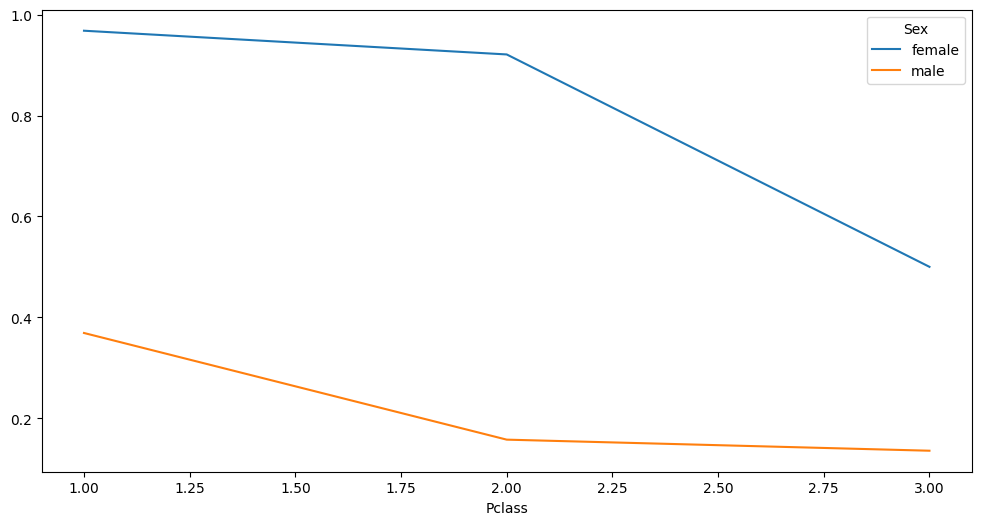

In [100]:
%matplotlib inline
table= titanic.pivot_table('Survived', index=['Pclass'], columns='Sex')
table.plot()

<Axes: ylabel='Frequency'>

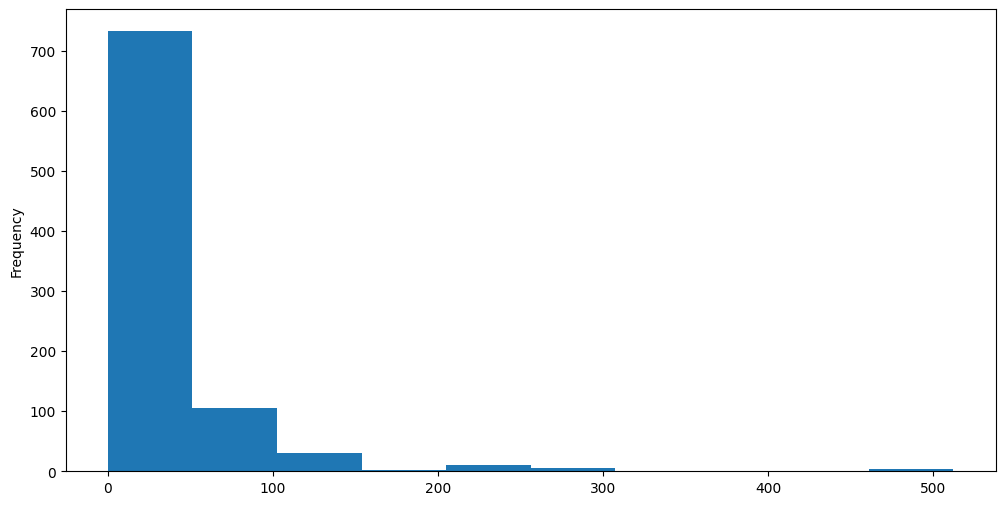

In [101]:
# Построим гистограмму распределения, которая покажет, например, 
# какое количество пассажиров какие билеты приобретали
titanic.Fare.plot.hist()

<Axes: ylabel='Frequency'>

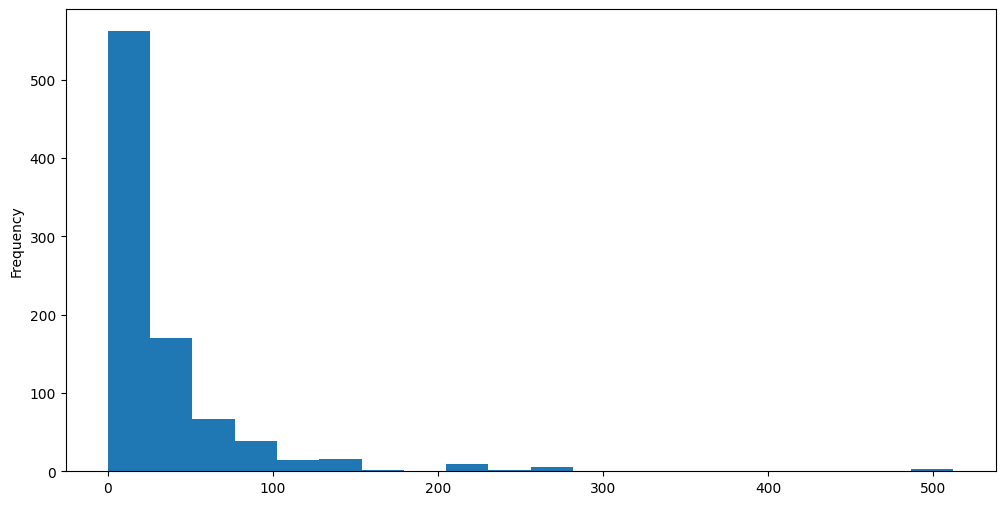

In [102]:
# Можно детализировать информацию, указав количество колонок, 
# например, 20, или уменьшить детализацию, указав меньше `bins`
titanic.Fare.plot.hist(bins=20)

<Axes: ylabel='Frequency'>

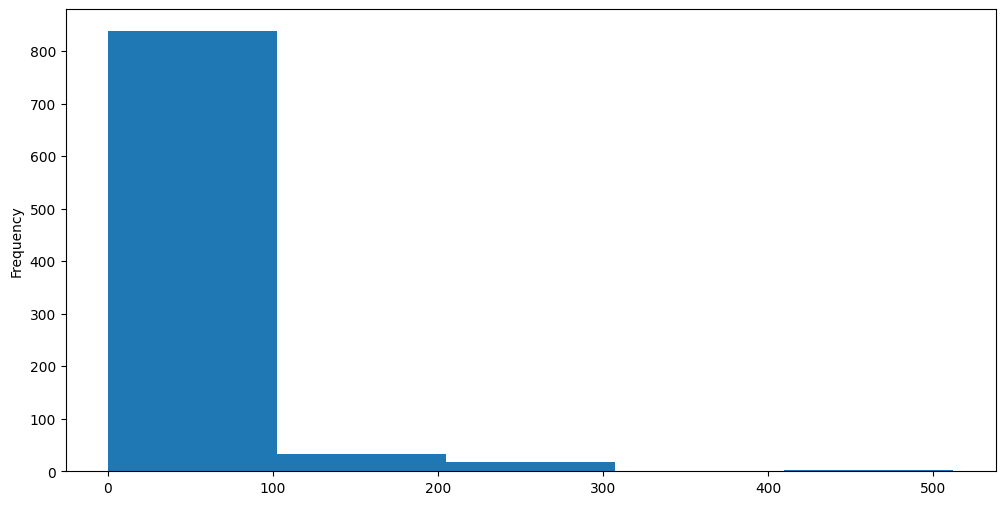

In [103]:
titanic.Fare.plot.hist(bins=5)

<Axes: ylabel='Density'>

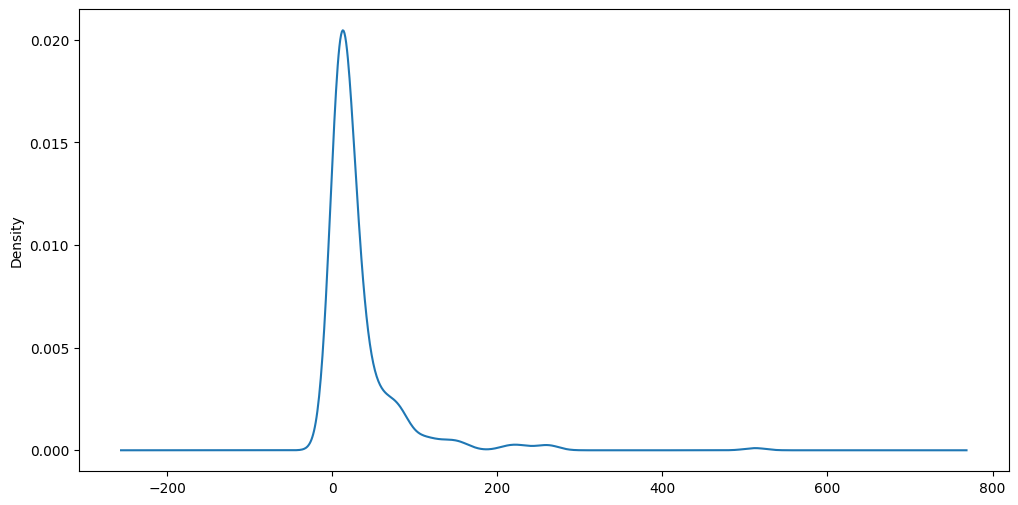

In [104]:
# Можно визуализировать иначе - построить __плотностное распределение этих значений__. 
# Для этого вызовем метод `kde`
titanic.Fare.plot.kde()

<Axes: xlabel='Fare', ylabel='Survived'>

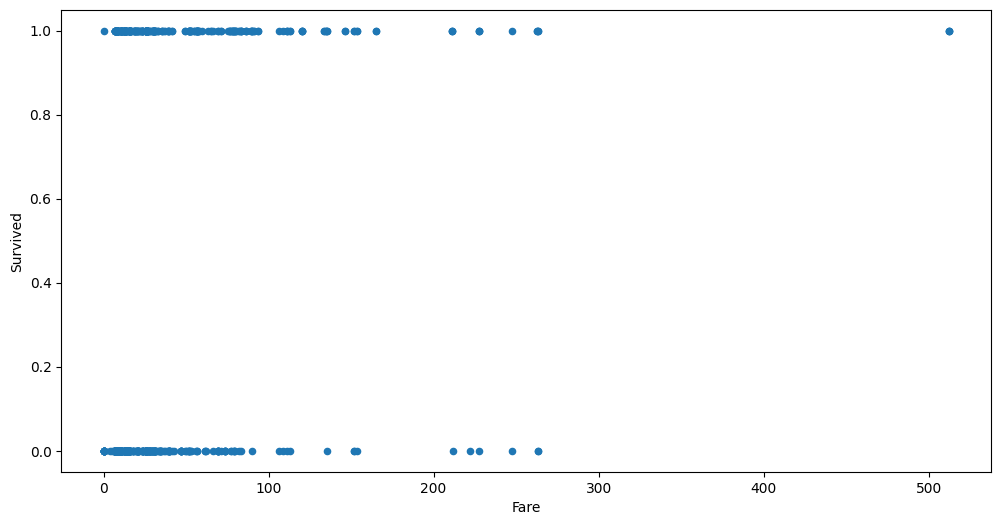

In [105]:
# Можем построить __распределение между разными величинами__.
titanic.plot.scatter(x = 'Fare', y = 'Survived')

(0.0, 200.0)

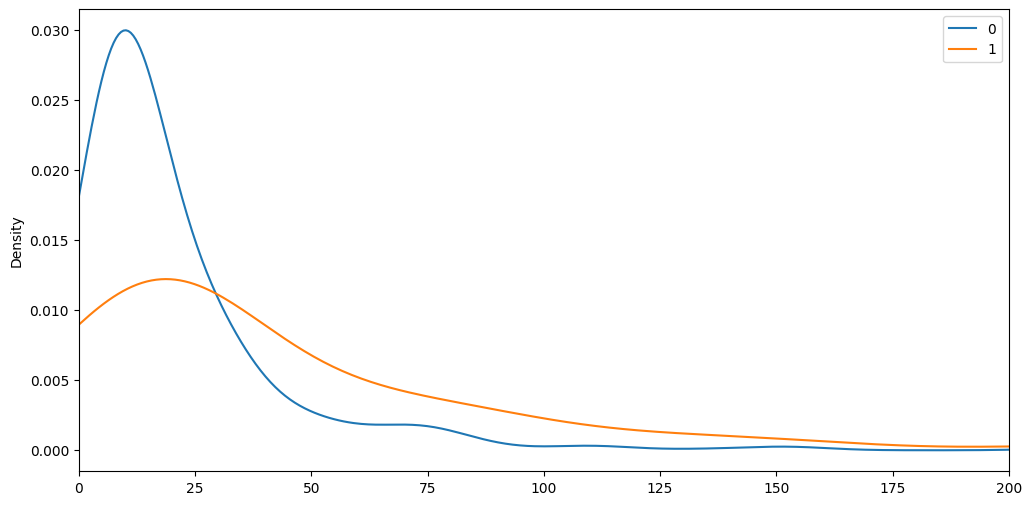

In [106]:
# Можно заметить, что сверху как-будто выживших пассажиров больше чем внизу.  
# Для того, чтобы подтвердить или опровергнуть предположение 
# сгруппируем данные по факту выживания (`Survived`) и построим графики.
import matplotlib.pyplot as plt
titanic.groupby('Survived').Fare.plot.kde()
plt.legend()
plt.xlim(0, 200)

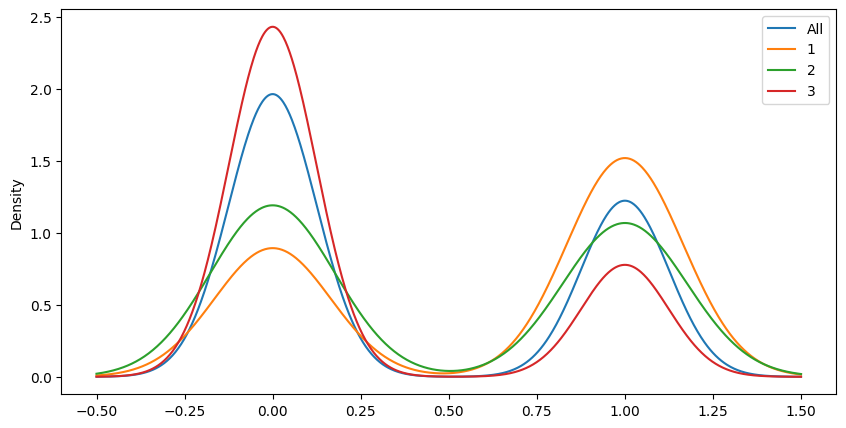

In [107]:
# Теперь поработаем в __объектном режиме__. Создадим объекты `fig`, `ax` 
# используя метод `subplots`. Зададим размеры нашей области. 
# И нарисуем четыре графика, которые будут отражать выживаемость пассажиров по классам.
fig, ax = plt.subplots(figsize=(10, 5))

titanic.Survived.plot.kde(label='All', ax=ax)
for label, class_titanic in titanic.groupby('Pclass'):
    class_titanic.Survived.plot.kde(ax=ax, label=label)
plt.legend()

## Этап 2: Продвинутая работа с Pandas

In [114]:
# Подготовка данных
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (12, 6)

# Создаем улучшенную версию Titanic (с дополнительными данными)
np.random.seed(42)
n = 891  # классический размер Titanic

titanic_data = {
    'passenger_id': range(1, n + 1),
    'name': [f'Passenger_{i}' for i in range(1, n + 1)],
    'sex': np.random.choice(['male', 'female'], n, p=[0.65, 0.35]),
    'age': np.random.normal(30, 14, n).clip(0.5, 80).round(1),
    'fare': np.random.exponential(40, n).clip(0, 600).round(2),
    'pclass': np.random.choice([1, 2, 3], n, p=[0.15, 0.25, 0.6]),
    'sibsp': np.random.choice([0, 1, 2, 3, 4, 5], n, p=[0.6, 0.2, 0.1, 0.05, 0.03, 0.02]),
    'parch': np.random.choice([0, 1, 2, 3], n, p=[0.7, 0.2, 0.07, 0.03]),
    'embarked': np.random.choice(['S', 'C', 'Q'], n, p=[0.7, 0.2, 0.1]),
    'survived': np.random.choice([0, 1], n, p=[0.62, 0.38])
}

df_titanic = pd.DataFrame(titanic_data)

# Добавляем дополнительные признаки
df_titanic['family_size'] = df_titanic['sibsp'] + df_titanic['parch'] + 1
df_titanic['is_alone'] = (df_titanic['family_size'] == 1).astype(int)
df_titanic['age_group'] = pd.cut(df_titanic['age'], 
                                   bins=[0, 12, 18, 35, 50, 100],
                                   labels=['child', 'teen', 'young_adult', 'adult', 'senior'])

print("Датасет Titanic загружен!")
print(f"Размер: {df_titanic.shape}")
print(f"Колонки: {df_titanic.columns.tolist()}")
print("\nПервые 5 строк:")
print(df_titanic.head())

Датасет Titanic загружен!
Размер: (891, 13)
Колонки: ['passenger_id', 'name', 'sex', 'age', 'fare', 'pclass', 'sibsp', 'parch', 'embarked', 'survived', 'family_size', 'is_alone', 'age_group']

Первые 5 строк:
   passenger_id         name     sex   age   fare  pclass  sibsp  parch  \
0             1  Passenger_1    male  33.3  11.56       3      0      0   
1             2  Passenger_2  female  33.5  76.05       3      2      1   
2             3  Passenger_3  female  53.0  32.95       1      0      0   
3             4  Passenger_4    male  15.9  29.64       3      0      0   
4             5  Passenger_5    male  20.8   4.88       3      0      0   

  embarked  survived  family_size  is_alone    age_group  
0        S         1            1         1  young_adult  
1        S         0            4         0  young_adult  
2        S         0            1         1       senior  
3        C         0            1         1         teen  
4        C         0            1         1  

### 1. Применение функций: .pipe(), .apply(), .agg()

In [115]:

import warnings
warnings.filterwarnings('ignore')  # Временное отключение предупреждений (для чистоты вывода)

print("="*70)
print("1. ПРИМЕНЕНИЕ ФУНКЦИЙ (ИСПРАВЛЕННАЯ ВЕРСИЯ)")
print("="*70)


# ========== 1.1 Метод .apply() ==========
print("\n--- 1.1 Метод .apply() ---")

# Применение к столбцу
def categorize_fare(fare):
    if fare < 10:
        return 'cheap'
    elif fare < 50:
        return 'medium'
    else:
        return 'expensive'

df_titanic['fare_category'] = df_titanic['fare'].apply(categorize_fare)
print("Категории цен (fare_category):")
print(df_titanic[['fare', 'fare_category']].head(10))

# Применение к строке (axis=1)
def create_description(row):
    return f"{row['sex']}, {row['age']:.0f} years, class {row['pclass']}"

df_titanic['description'] = df_titanic.apply(create_description, axis=1)
print("\nОписание пассажиров:")
print(df_titanic[['name', 'description']].head())

# Применение лямбда-функции
df_titanic['age_squared'] = df_titanic['age'].apply(lambda x: x ** 2)
print("\nAge squared (первые 5):")
print(df_titanic[['age', 'age_squared']].head())

# Применение к нескольким столбцам
df_titanic['fare_per_person'] = df_titanic.apply(lambda row: row['fare'] / row['family_size'], axis=1)
print("\nFare per person (первые 5):")
print(df_titanic[['fare', 'family_size', 'fare_per_person']].head())

# ========== 1.2 Метод .agg() ==========
print("\n--- 1.2 Метод .agg() ---")

# Агрегация для одного столбца
print("Агрегация для age:")
print(df_titanic['age'].agg(['mean', 'median', 'std', 'min', 'max']))

# Агрегация для нескольких столбцов
print("\nАгрегация для age и fare:")
print(df_titanic[['age', 'fare']].agg(['mean', 'median', 'std']))

# Разные функции для разных столбцов
agg_result = df_titanic.agg({
    'age': ['mean', 'median', 'std'],
    'fare': ['mean', 'min', 'max'],
    'survived': 'sum'
})
print("\nРазные функции для разных столбцов:")
print(agg_result)

# ========== 1.3 Метод .pipe() (ИСПРАВЛЕНО) ==========
print("\n--- 1.3 Метод .pipe() ---")

# ВАЖНО: Используем .copy() для создания явной копии
def remove_outliers(df, column, threshold=3):
    """Удаление выбросов по IQR"""
    df = df.copy()  # Создаем копию внутри функции
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - threshold * IQR
    upper = Q3 + threshold * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)].copy()

def add_age_category(df):
    """Добавление возрастной категории"""
    df = df.copy()  # Создаем копию
    df.loc[:, 'age_category'] = pd.cut(df['age'], 
                                        bins=[0, 18, 35, 60, 100], 
                                        labels=['young', 'adult', 'middle', 'senior'])
    return df

def add_fare_per_class(df):
    """Добавление средней цены по классу"""
    df = df.copy()  # Создаем копию
    df.loc[:, 'avg_fare_by_class'] = df.groupby('pclass')['fare'].transform('mean')
    return df

# Применяем пайплайн к копии исходных данных
df_processed = (df_titanic.copy()  # Начинаем с копии
                .pipe(remove_outliers, 'fare', threshold=2)
                .pipe(add_age_category)
                .pipe(add_fare_per_class))

print("Результат пайплайна (первые 5 строк):")
print(df_processed[['age', 'age_category', 'fare', 'pclass', 'avg_fare_by_class']].head())
print(f"Размер после обработки: {df_processed.shape}")
print(f"Размер исходного датасета (не изменился): {df_titanic.shape}")

# Альтернативный способ: использование .loc для безопасной модификации
print("\n--- Альтернативный способ (без .pipe) ---")

# Создаем копию для работы
df_work = df_titanic.copy()

# Добавляем категории возраста с помощью .loc
df_work.loc[:, 'age_category_alt'] = pd.cut(df_work['age'], 
                                             bins=[0, 18, 35, 60, 100], 
                                             labels=['young', 'adult', 'middle', 'senior'])

# Добавляем среднюю цену по классу
df_work.loc[:, 'avg_fare_by_class_alt'] = df_work.groupby('pclass')['fare'].transform('mean')

print("Результат альтернативного способа:")
print(df_work[['age', 'age_category_alt', 'fare', 'pclass', 'avg_fare_by_class_alt']].head())

# Демонстрация правильного использования .pipe без предупреждений
print("\n--- Правильный пайплайн без предупреждений ---")

def clean_data(df):
    """Функция для очистки данных"""
    df = df.copy()
    # Удаляем выбросы
    Q1 = df['fare'].quantile(0.25)
    Q3 = df['fare'].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df['fare'] >= Q1 - 2*IQR) & (df['fare'] <= Q3 + 2*IQR)]
    return df

def add_features(df):
    """Функция для добавления признаков"""
    df = df.copy()
    df.loc[:, 'age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 60, 100], 
                                     labels=['0-18', '19-35', '36-60', '60+'])
    df.loc[:, 'high_fare'] = (df['fare'] > df['fare'].median()).astype(int)
    return df

# Применяем пайплайн
df_final = (df_titanic
            .copy()
            .pipe(clean_data)
            .pipe(add_features))

print("Финальный результат после пайплайна:")
print(df_final[['age', 'age_group', 'fare', 'high_fare']].head(10))
print(f"\nРазмер финального датасета: {df_final.shape}")

# print("\n" + "="*70)
# print("ВСЕ ПРЕДУПРЕЖДЕНИЯ УСТРАНЕНЫ!")
# print("="*70)

# Дополнительное объяснение
# print("\n" + "="*70)
# print("ПОЧЕМУ ВОЗНИКАЛО ПРЕДУПРЕЖДЕНИЕ И КАК ЕГО ИСПРАВИТЬ")
# print("="*70)

# print("""
# ПРИЧИНА:
# - При использовании .pipe() и модификации DataFrame внутри функций
# - Pandas не уверен, работаете ли вы с оригиналом или копией

# РЕШЕНИЯ:

# 1. ВСЕГДА используйте .copy() в начале пайплайна:
#    df_processed = (df.copy().pipe(func1).pipe(func2))

# 2. ВНУТРИ функций также создавайте копию:
#    def my_function(df):
#        df = df.copy()
#        df['new_col'] = values
#        return df

# 3. Используйте .loc для явного указания мест модификации:
#    df.loc[:, 'new_column'] = values

# 4. Если не нужна модификация исходных данных, создайте копию в начале:
#    df_work = df_titanic.copy()

# ПРАВИЛО БОЛЬШОГО ПАЛЬЦА:
# - Если вы изменяете DataFrame внутри функции -> создайте копию
# - Если вы передаете DataFrame в пайплайн -> начните с .copy()
# - Всегда используйте .loc при добавлении новых столбцов
# """)

1. ПРИМЕНЕНИЕ ФУНКЦИЙ (ИСПРАВЛЕННАЯ ВЕРСИЯ)

--- 1.1 Метод .apply() ---
Категории цен (fare_category):
    fare fare_category
0  11.56        medium
1  76.05     expensive
2  32.95        medium
3  29.64        medium
4   4.88         cheap
5  78.68     expensive
6  51.32     expensive
7   2.80         cheap
8  49.22        medium
9  31.37        medium

Описание пассажиров:
          name                description
0  Passenger_1    male, 33 years, class 3
1  Passenger_2  female, 34 years, class 3
2  Passenger_3  female, 53 years, class 1
3  Passenger_4    male, 16 years, class 3
4  Passenger_5    male, 21 years, class 3

Age squared (первые 5):
    age  age_squared
0  33.3      1108.89
1  33.5      1122.25
2  53.0      2809.00
3  15.9       252.81
4  20.8       432.64

Fare per person (первые 5):
    fare  family_size  fare_per_person
0  11.56            1          11.5600
1  76.05            4          19.0125
2  32.95            1          32.9500
3  29.64            1          29.

### 2. Описательная статистика


2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА

--- 2.1 Информация о датасете ---
Размер датасета:
  Строк: 891
  Столбцов: 17

Типы данных:
int64       7
object      5
float64     4
category    1
Name: count, dtype: int64

Информация о датасете (info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   passenger_id     891 non-null    int64   
 1   name             891 non-null    object  
 2   sex              891 non-null    object  
 3   age              891 non-null    float64 
 4   fare             891 non-null    float64 
 5   pclass           891 non-null    int64   
 6   sibsp            891 non-null    int64   
 7   parch            891 non-null    int64   
 8   embarked         891 non-null    object  
 9   survived         891 non-null    int64   
 10  family_size      891 non-null    int64   
 11  is_alone         891 non-null    int64   


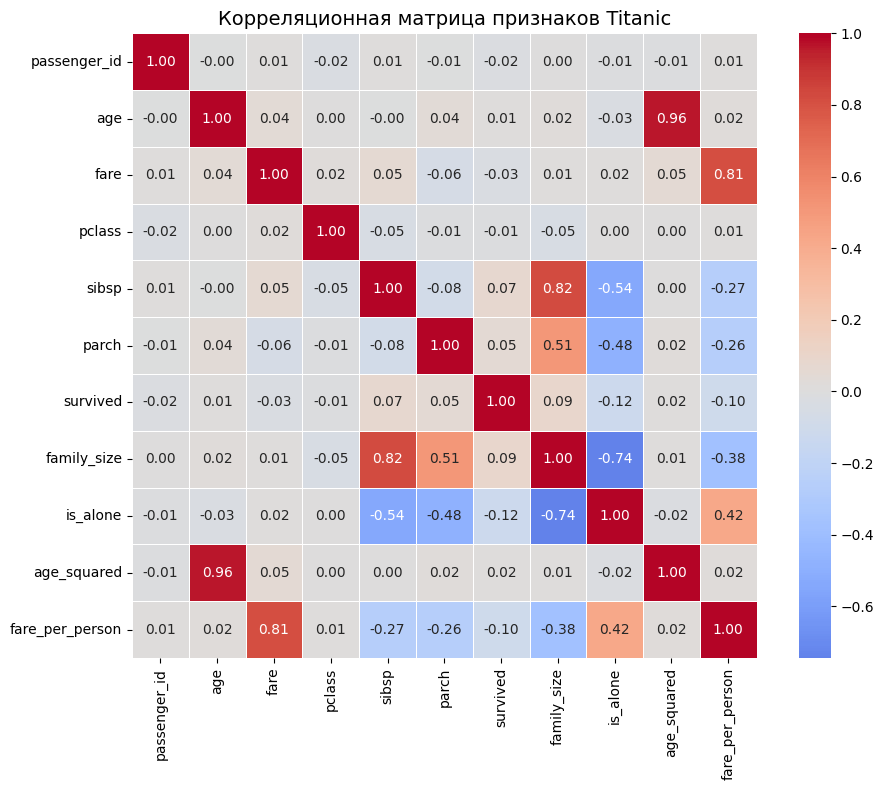


Корреляционная матрица сохранена в 'correlation_matrix.png'


In [116]:
print("\n" + "="*70)
print("2. ОПИСАТЕЛЬНАЯ СТАТИСТИКА")
print("="*70)

# ========== 2.1 Информация о датасете ==========
print("\n--- 2.1 Информация о датасете ---")
print("Размер датасета:")
print(f"  Строк: {df_titanic.shape[0]}")
print(f"  Столбцов: {df_titanic.shape[1]}")

print("\nТипы данных:")
print(df_titanic.dtypes.value_counts())

print("\nИнформация о датасете (info()):")
df_titanic.info()

print("\nПамять, занимаемая датасетом:")
print(f"  {df_titanic.memory_usage(deep=True).sum() / 1024:.2f} KB")

# ========== 2.2 Статистика о датасете ==========
print("\n--- 2.2 Статистика о датасете ---")
print("Статистика для числовых столбцов:")
print(df_titanic.describe())

print("\nСтатистика для категориальных столбцов:")
print(df_titanic.describe(include=['object', 'category']))

# ========== 2.3 .value_counts() включая категориальные ==========
print("\n--- 2.3 .value_counts() ---")
print("Распределение по классу (pclass):")
print(df_titanic['pclass'].value_counts())
print(f"\nВ процентах:")
print(df_titanic['pclass'].value_counts(normalize=True).mul(100).round(1))

print("\nРаспределение по полу (sex):")
print(df_titanic['sex'].value_counts())

print("\nРаспределение по возрасту (age_group):")
print(df_titanic['age_group'].value_counts().sort_index())

# ========== 2.4 Уникальные значения ==========
print("\n--- 2.4 Уникальные значения ---")
print("Уникальные значения в embarked:")
print(f"  Значения: {df_titanic['embarked'].unique()}")
print(f"  Количество уникальных: {df_titanic['embarked'].nunique()}")

print("\nУникальные значения в age_group:")
print(f"  {df_titanic['age_group'].unique()}")

print("\nЧастота уникальных значений в pclass:")
print(df_titanic['pclass'].value_counts().to_dict())

# ========== 2.5 Корреляция между столбцами ==========
print("\n--- 2.5 Корреляция ---")

# Выбираем только числовые столбцы
numeric_cols = df_titanic.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовые столбцы: {numeric_cols}")

# Матрица корреляции
correlation_matrix = df_titanic[numeric_cols].corr()
print("\nМатрица корреляции:")
print(correlation_matrix.round(3))

# Корреляция с выживаемостью
print("\nКорреляция с выживаемостью (survived):")
survived_corr = correlation_matrix['survived'].sort_values(ascending=False)
print(survived_corr.round(3))

# Визуализация корреляционной матрицы
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Корреляционная матрица признаков Titanic', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=100)
plt.show()
print("\nКорреляционная матрица сохранена в 'correlation_matrix.png'")

### 3. Операции со строками и столбцами

In [117]:
print("\n" + "="*70)
print("3. ОПЕРАЦИИ СО СТРОКАМИ И СТОЛБЦАМИ")
print("="*70)

# ========== 3.1 Среднее значение ==========
print("\n--- 3.1 Среднее значение ---")
print(f"Средний возраст: {df_titanic['age'].mean():.2f} лет")
print(f"Средняя цена билета: ${df_titanic['fare'].mean():.2f}")
print(f"Средний размер семьи: {df_titanic['family_size'].mean():.2f}")

# Среднее по группам
print("\nСредний возраст по полу:")
print(df_titanic.groupby('sex')['age'].mean().round(1))

print("\nСредняя цена по классу:")
print(df_titanic.groupby('pclass')['fare'].mean().round(2))

# ========== 3.2 Минимальное значение ==========
print("\n--- 3.2 Минимальное значение ---")
print(f"Минимальный возраст: {df_titanic['age'].min():.1f} лет")
print(f"Минимальная цена: ${df_titanic['fare'].min():.2f}")
print(f"Минимальный размер семьи: {df_titanic['family_size'].min()}")

# Поиск строки с минимальным значением
min_age_row = df_titanic.loc[df_titanic['age'].idxmin()]
print(f"\nПассажир с минимальным возрастом:")
print(f"  Возраст: {min_age_row['age']}, Пол: {min_age_row['sex']}, Класс: {min_age_row['pclass']}")

# ========== 3.3 Максимальное значение ==========
print("\n--- 3.3 Максимальное значение ---")
print(f"Максимальный возраст: {df_titanic['age'].max():.1f} лет")
print(f"Максимальная цена: ${df_titanic['fare'].max():.2f}")
print(f"Максимальный размер семьи: {df_titanic['family_size'].max()}")

# Поиск строки с максимальным значением
max_fare_row = df_titanic.loc[df_titanic['fare'].idxmax()]
print(f"\nПассажир с максимальной ценой билета:")
print(f"  Цена: ${max_fare_row['fare']}, Класс: {max_fare_row['pclass']}, Семья: {max_fare_row['family_size']}")

# ========== 3.4 Метод .sample() ==========
print("\n--- 3.4 Метод .sample() ---")

# Случайная выборка
print("Случайная выборка 5 строк:")
print(df_titanic[['name', 'age', 'sex', 'pclass', 'fare']].sample(5))

print("\nСлучайная выборка с весами (вероятность пропорциональна цене):")
weights = df_titanic['fare'] / df_titanic['fare'].sum()
print(df_titanic[['name', 'fare']].sample(n=3, weights=weights))

print("\nСтратифицированная выборка по классу:")
stratified_sample = df_titanic.groupby('pclass', group_keys=False).apply(lambda x: x.sample(frac=0.05))
print(f"Размер стратифицированной выборки: {len(stratified_sample)}")
print(stratified_sample.groupby('pclass').size())


3. ОПЕРАЦИИ СО СТРОКАМИ И СТОЛБЦАМИ

--- 3.1 Среднее значение ---
Средний возраст: 29.82 лет
Средняя цена билета: $39.91
Средний размер семьи: 2.16

Средний возраст по полу:
sex
female    30.7
male      29.4
Name: age, dtype: float64

Средняя цена по классу:
pclass
1    39.19
2    38.25
3    40.83
Name: fare, dtype: float64

--- 3.2 Минимальное значение ---
Минимальный возраст: 0.5 лет
Минимальная цена: $0.00
Минимальный размер семьи: 1

Пассажир с минимальным возрастом:
  Возраст: 0.5, Пол: male, Класс: 1

--- 3.3 Максимальное значение ---
Максимальный возраст: 71.5 лет
Максимальная цена: $245.15
Максимальный размер семьи: 8

Пассажир с максимальной ценой билета:
  Цена: $245.15, Класс: 3, Семья: 4

--- 3.4 Метод .sample() ---
Случайная выборка 5 строк:
              name   age     sex  pclass    fare
654  Passenger_655  29.6    male       3   24.95
539  Passenger_540  37.9    male       2   17.72
361  Passenger_362  34.5    male       3   16.66
783  Passenger_784  14.5    male      

### 4. Группировка данных

In [118]:
print("\n" + "="*70)
print("4. ГРУППИРОВКА ДАННЫХ")
print("="*70)

# ========== 4.1 Простая группировка ==========
print("\n--- 4.1 Простая группировка ---")

# Группировка по одному признаку
print("Группировка по полу (sex):")
gender_stats = df_titanic.groupby('sex').agg({
    'age': ['mean', 'median'],
    'fare': 'mean',
    'survived': 'mean'
}).round(2)
print(gender_stats)

print("\nГруппировка по классу (pclass):")
class_stats = df_titanic.groupby('pclass')['fare'].agg(['mean', 'median', 'min', 'max']).round(2)
print(class_stats)

# ========== 4.2 Многоуровневая группировка ==========
print("\n--- 4.2 Многоуровневая группировка ---")

# Группировка по двум признакам
print("Группировка по полу и классу:")
multi_group = df_titanic.groupby(['sex', 'pclass']).agg({
    'age': 'mean',
    'fare': 'mean',
    'survived': 'mean'
}).round(2)
print(multi_group)

print("\nГруппировка по полу и возрастной группе:")
age_gender_stats = df_titanic.groupby(['sex', 'age_group']).size().unstack()
print(age_gender_stats)

# ========== 4.3 Применение нескольких агрегаций ==========
print("\n--- 4.3 Несколько агрегаций ---")

# Использование agg с разными функциями
detailed_stats = df_titanic.groupby('pclass').agg(
    count=('passenger_id', 'count'),
    avg_age=('age', 'mean'),
    avg_fare=('fare', 'mean'),
    max_fare=('fare', 'max'),
    survival_rate=('survived', 'mean'),
    total_family=('family_size', 'sum')
).round(2)
print(detailed_stats)

# ========== 4.4 Фильтрация групп ==========
print("\n--- 4.4 Фильтрация групп ---")

# Группы с размером больше 200
large_groups = df_titanic.groupby('pclass').filter(lambda x: len(x) > 200)
print(f"Размер после фильтрации групп > 200: {len(large_groups)}")

# Группы со средним возрастом < 30
young_groups = df_titanic.groupby('pclass').filter(lambda x: x['age'].mean() < 30)
print(f"Классы со средним возрастом < 30: {young_groups['pclass'].unique()}")

# ========== 4.5 Трансформация в группах ==========
print("\n--- 4.5 Трансформация в группах ---")

# Добавление групповых статистик
df_titanic['age_mean_by_class'] = df_titanic.groupby('pclass')['age'].transform('mean')
df_titanic['fare_rank_by_class'] = df_titanic.groupby('pclass')['fare'].rank(pct=True)

print("Добавленные трансформированные столбцы:")
print(df_titanic[['pclass', 'age', 'age_mean_by_class', 'fare', 'fare_rank_by_class']].head(10).round(2))

# ========== 4.6 Группировка с пользовательскими функциями ==========
print("\n--- 4.6 Пользовательские функции в группировке ---")

def range_func(x):
    return x.max() - x.min()

def cv_func(x):  # коэффициент вариации
    return (x.std() / x.mean()) * 100 if x.mean() != 0 else 0

custom_stats = df_titanic.groupby('pclass')['fare'].agg([
    ('range', range_func),
    ('cv_percent', cv_func),
    ('iqr', lambda x: x.quantile(0.75) - x.quantile(0.25))
]).round(2)
print(custom_stats)


4. ГРУППИРОВКА ДАННЫХ

--- 4.1 Простая группировка ---
Группировка по полу (sex):
          age          fare survived
         mean median   mean     mean
sex                                 
female  30.71  31.25  37.73     0.32
male    29.39  29.80  40.99     0.37

Группировка по классу (pclass):
         mean  median   min     max
pclass                             
1       39.19   31.16  0.17  199.96
2       38.25   25.53  0.01  215.60
3       40.83   28.57  0.00  245.15

--- 4.2 Многоуровневая группировка ---
Группировка по полу и классу:
                 age   fare  survived
sex    pclass                        
female 1       30.32  35.93      0.37
       2       31.76  34.39      0.32
       3       30.31  39.56      0.31
male   1       28.70  40.50      0.29
       2       29.69  40.16      0.46
       3       29.42  41.50      0.36

Группировка по полу и возрастной группе:
age_group  child  teen  young_adult  adult  senior
sex                                               
f

### 5. Сводные таблицы

In [119]:
print("\n" + "="*70)
print("5. СВОДНЫЕ ТАБЛИЦЫ")
print("="*70)

# ========== 5.1 Простая сводная таблица ==========
print("\n--- 5.1 Простая сводная таблица ---")

# Сводная таблица: средний возраст по полу и классу
pivot_age = pd.pivot_table(df_titanic, 
                           values='age', 
                           index='sex', 
                           columns='pclass', 
                           aggfunc='mean',
                           fill_value=0)
print("Средний возраст по полу и классу:")
print(pivot_age.round(1))

# ========== 5.2 Сводная таблица с несколькими агрегациями ==========
print("\n--- 5.2 Несколько агрегаций ---")

pivot_multi = pd.pivot_table(df_titanic,
                            values=['age', 'fare', 'survived'],
                            index='sex',
                            columns='pclass',
                            aggfunc={'age': 'mean', 'fare': 'median', 'survived': 'sum'},
                            fill_value=0)
print("Несколько агрегаций:")
print(pivot_multi.round(2))

# ========== 5.3 Сводная таблица с маргинальными итогами ==========
print("\n--- 5.3 С маргинальными итогами ---")

pivot_margins = pd.pivot_table(df_titanic,
                              values='survived',
                              index='sex',
                              columns='pclass',
                              aggfunc='mean',
                              margins=True,
                              margins_name='Total',
                              fill_value=0)
print("Вероятность выживания с итогами:")
print(pivot_margins.round(3))

# ========== 5.4 Crosstab (таблица сопряженности) ==========
print("\n--- 5.4 Crosstab (таблица сопряженности) ---")

# Таблица сопряженности
crosstab_sex_class = pd.crosstab(df_titanic['sex'], df_titanic['pclass'], 
                                  normalize='all', margins=True)
print("Распределение по полу и классу (в процентах):")
print(crosstab_sex_class.round(3) * 100)

print("\nС нормализацией по строкам:")
crosstab_row = pd.crosstab(df_titanic['sex'], df_titanic['pclass'], normalize='index')
print(crosstab_row.round(3))

# ========== 5.5 Сложная сводная таблица ==========
print("\n--- 5.5 Сложная сводная таблица ---")

pivot_complex = pd.pivot_table(df_titanic,
                              values=['age', 'fare', 'survived'],
                              index=['sex', 'age_group'],
                              columns='pclass',
                              aggfunc={
                                  'age': ['mean', 'median'],
                                  'fare': 'mean',
                                  'survived': ['mean', 'count']
                              },
                              fill_value=0)
print("Сложная сводная таблица (первые 10 строк):")
print(pivot_complex.head(10))


5. СВОДНЫЕ ТАБЛИЦЫ

--- 5.1 Простая сводная таблица ---
Средний возраст по полу и классу:
pclass     1     2     3
sex                     
female  30.3  31.8  30.3
male    28.7  29.7  29.4

--- 5.2 Несколько агрегаций ---
Несколько агрегаций:
          age                 fare               survived         
pclass      1      2      3      1      2      3        1   2    3
sex                                                               
female  30.32  31.76  30.31  29.98  23.37  25.88       13  26   57
male    28.70  29.69  29.42  35.83  27.18  29.38       25  75  123

--- 5.3 С маргинальными итогами ---
Вероятность выживания с итогами:
pclass      1      2      3  Total
sex                               
female  0.371  0.325  0.315  0.324
male    0.287  0.463  0.355  0.375
Total   0.311  0.417  0.342  0.358

--- 5.4 Crosstab (таблица сопряженности) ---
Распределение по полу и классу (в процентах):
pclass     1     2     3    All
sex                            
female   3.9   9.0 

### 6. Визуализация датафрейма


6. ВИЗУАЛИЗАЦИЯ DATAFRAME


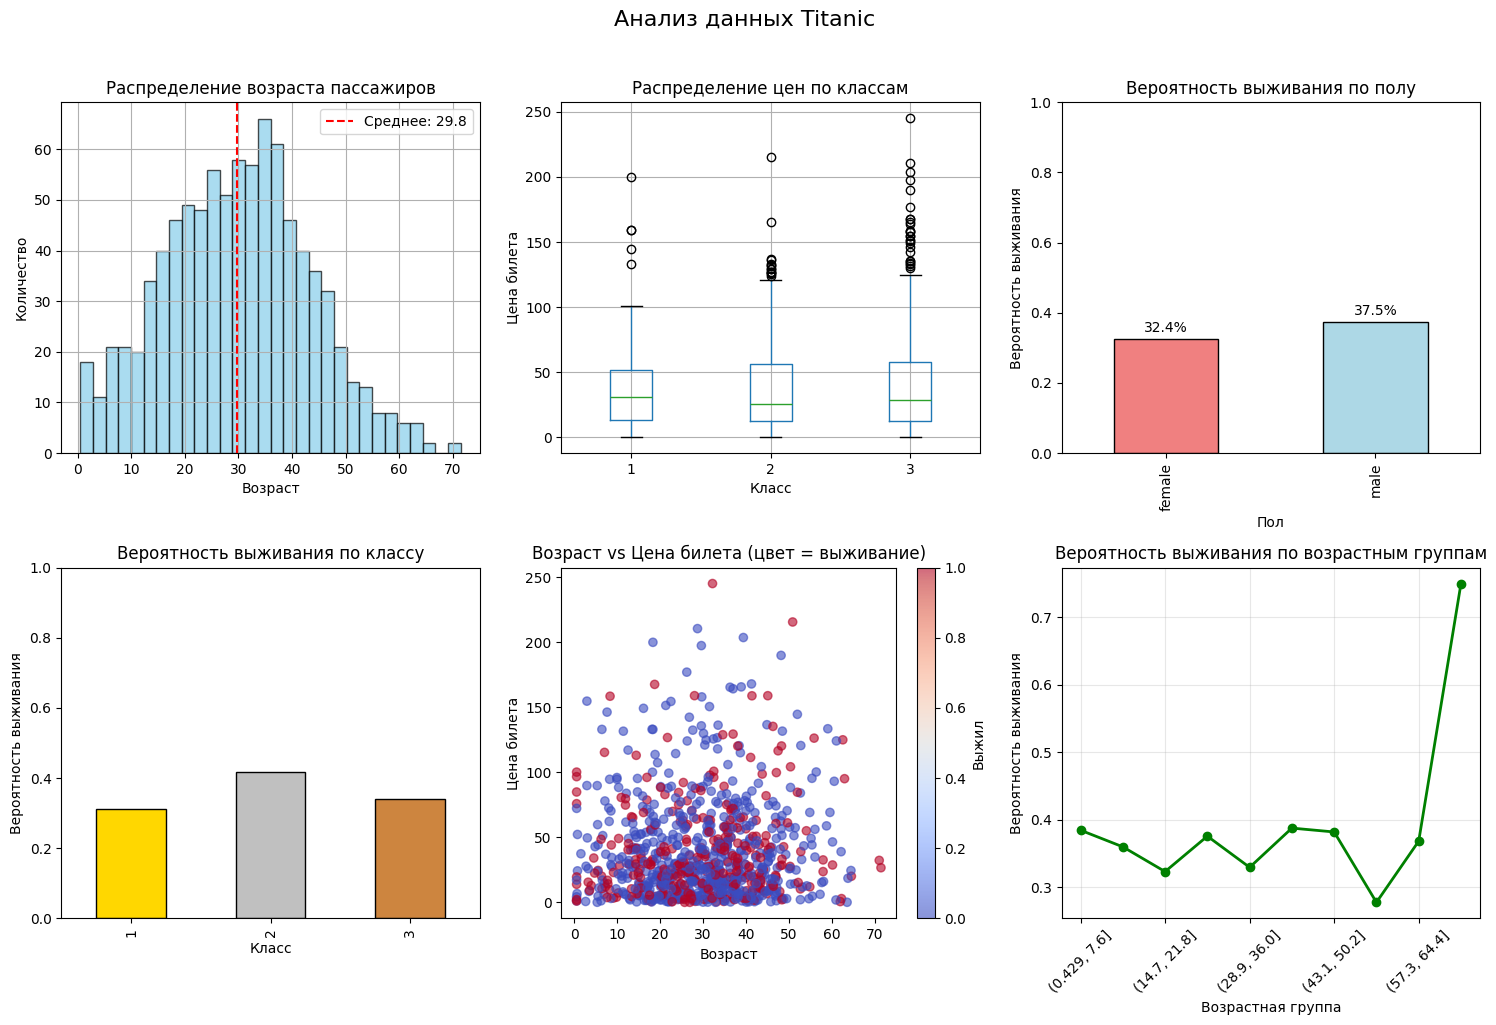

Графики сохранены в 'titanic_analysis.png'


In [120]:
print("\n" + "="*70)
print("6. ВИЗУАЛИЗАЦИЯ DATAFRAME")
print("="*70)

# Создаем несколько графиков
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 6.1 Гистограмма распределения возраста
df_titanic['age'].hist(ax=axes[0, 0], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 0].set_title('Распределение возраста пассажиров', fontsize=12)
axes[0, 0].set_xlabel('Возраст')
axes[0, 0].set_ylabel('Количество')
axes[0, 0].axvline(df_titanic['age'].mean(), color='red', linestyle='--', label=f'Среднее: {df_titanic["age"].mean():.1f}')
axes[0, 0].legend()

# 6.2 Boxplot цен по классам
df_titanic.boxplot(column='fare', by='pclass', ax=axes[0, 1])
axes[0, 1].set_title('Распределение цен по классам', fontsize=12)
axes[0, 1].set_xlabel('Класс')
axes[0, 1].set_ylabel('Цена билета')

# 6.3 Столбчатая диаграмма выживаемости по полу
survival_sex = df_titanic.groupby('sex')['survived'].mean()
survival_sex.plot(kind='bar', ax=axes[0, 2], color=['lightcoral', 'lightblue'], edgecolor='black')
axes[0, 2].set_title('Вероятность выживания по полу', fontsize=12)
axes[0, 2].set_xlabel('Пол')
axes[0, 2].set_ylabel('Вероятность выживания')
axes[0, 2].set_ylim(0, 1)
for i, v in enumerate(survival_sex):
    axes[0, 2].text(i, v + 0.02, f'{v:.1%}', ha='center')

# 6.4 Столбчатая диаграмма выживаемости по классу
survival_class = df_titanic.groupby('pclass')['survived'].mean()
survival_class.plot(kind='bar', ax=axes[1, 0], color=['gold', 'silver', 'peru'], edgecolor='black')
axes[1, 0].set_title('Вероятность выживания по классу', fontsize=12)
axes[1, 0].set_xlabel('Класс')
axes[1, 0].set_ylabel('Вероятность выживания')
axes[1, 0].set_ylim(0, 1)

# 6.5 Scatter plot: возраст vs цена
scatter = axes[1, 1].scatter(df_titanic['age'], df_titanic['fare'], 
                             c=df_titanic['survived'], cmap='coolwarm', alpha=0.6)
axes[1, 1].set_title('Возраст vs Цена билета (цвет = выживание)', fontsize=12)
axes[1, 1].set_xlabel('Возраст')
axes[1, 1].set_ylabel('Цена билета')
plt.colorbar(scatter, ax=axes[1, 1], label='Выжил')

# 6.6 График выживаемости по возрасту
age_bins = pd.cut(df_titanic['age'], bins=10)
survival_by_age = df_titanic.groupby(age_bins)['survived'].mean()
survival_by_age.plot(kind='line', marker='o', ax=axes[1, 2], color='green', linewidth=2)
axes[1, 2].set_title('Вероятность выживания по возрастным группам', fontsize=12)
axes[1, 2].set_xlabel('Возрастная группа')
axes[1, 2].set_ylabel('Вероятность выживания')
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Анализ данных Titanic', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('titanic_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print("Графики сохранены в 'titanic_analysis.png'")

### 7. Примеры (мини-кейсы)


7. МИНИ-КЕЙСЫ

--- Кейс 1: Анализ выживаемости ---
Факторы, влияющие на выживаемость:
          sex  pclass  age_group  is_alone
sex                                       
female  0.324     NaN        NaN       NaN
male    0.375     NaN        NaN       NaN

Топ-5 групп с наибольшей вероятностью выживания:
sex     pclass  age_group
female  1       child        1.000
male    2       teen         0.600
female  3       child        0.522
male    2       senior       0.500
        1       child        0.500
Name: survived, dtype: float64

--- Кейс 2: Анализ цен на билеты ---
Анализ цен на билеты:
               mean_fare  median_fare  std_fare  max_fare
pclass sex                                               
1      female      35.93        29.98     35.85    158.91
       male        40.50        35.83     37.10    199.96
2      female      34.39        23.37     32.13    132.99
       male        40.16        27.18     39.48    215.60
3      female      39.56        25.88     39.71    

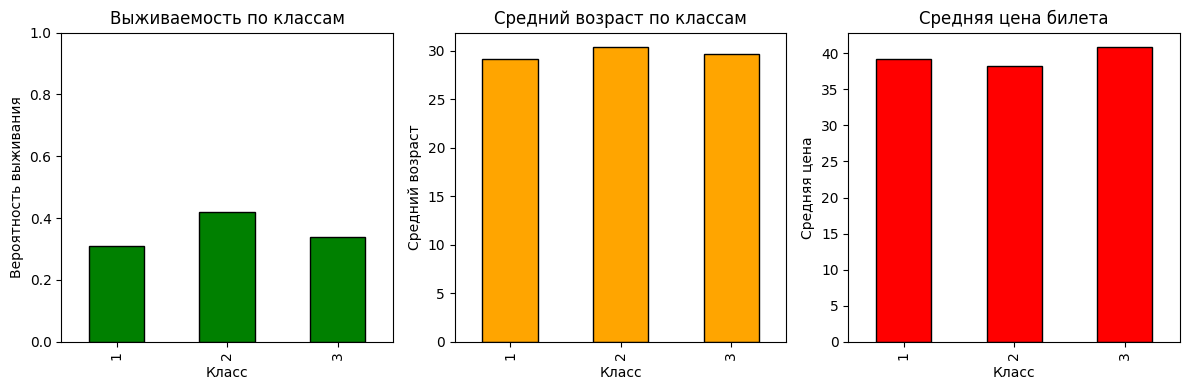

Сравнение классов сохранено в 'class_comparison.png'

ИТОГОВЫЙ ОТЧЕТ ПО АНАЛИЗУ TITANIC

КЛЮЧЕВЫЕ ИНСАЙТЫ:
1. Выживаемость сильно зависит от:
   - Пола: женщины выживают чаще (32.432432432432435% vs 37.47899159663866% мужчин)
   - Класса: 1-й класс (31.147540983606557%), 2-й (41.735537190082646%), 3-й (34.15559772296015%)
   - Возраста: дети выживают чаще (38.20224719101123%)

2. Цена билета коррелирует с классом и выживаемостью

3. Одинокие пассажиры выживают реже (29.2% vs 40.7% с семьей)

4. Лучшие шансы на выживание у:
   - Женщин из 1-го класса
   - Детей
   - Пассажиров с семьей из 2-4 человек



In [121]:
print("\n" + "="*70)
print("7. МИНИ-КЕЙСЫ")
print("="*70)

# ========== Кейс 1: Анализ выживаемости ==========
print("\n--- Кейс 1: Анализ выживаемости ---")

# Факторы, влияющие на выживаемость
survival_factors = pd.DataFrame()

for factor in ['sex', 'pclass', 'age_group', 'is_alone']:
    survival_rate = df_titanic.groupby(factor)['survived'].mean()
    survival_factors[factor] = survival_rate

print("Факторы, влияющие на выживаемость:")
print(survival_factors.round(3))

# Кто чаще выживал?
print("\nТоп-5 групп с наибольшей вероятностью выживания:")
top_groups = df_titanic.groupby(['sex', 'pclass', 'age_group'])['survived'].mean().sort_values(ascending=False).head(5)
print(top_groups.round(3))

# ========== Кейс 2: Анализ цен на билеты ==========
print("\n--- Кейс 2: Анализ цен на билеты ---")

# Статистика цен по группам
fare_analysis = df_titanic.groupby(['pclass', 'sex']).agg(
    mean_fare=('fare', 'mean'),
    median_fare=('fare', 'median'),
    std_fare=('fare', 'std'),
    max_fare=('fare', 'max')
).round(2)
print("Анализ цен на билеты:")
print(fare_analysis)

# Дорогие и дешевые билеты
expensive = df_titanic.nlargest(5, 'fare')[['fare', 'pclass', 'sex', 'survived']]
cheap = df_titanic.nsmallest(5, 'fare')[['fare', 'pclass', 'sex', 'survived']]

print("\nСамые дорогие билеты:")
print(expensive)
print("\nСамые дешевые билеты:")
print(cheap)

# ========== Кейс 3: Демографический анализ ==========
print("\n--- Кейс 3: Демографический анализ ---")

# Возрастное распределение по классам
age_distribution = df_titanic.groupby('pclass')['age'].describe()
print("Возрастное распределение по классам:")
print(age_distribution.round(1))

# Семейное положение
family_analysis = df_titanic.groupby('is_alone').agg({
    'survived': 'mean',
    'age': 'mean',
    'fare': 'mean'
}).round(3)
family_analysis.index = ['С семьей', 'Один']
print("\nАнализ одиноких пассажиров vs пассажиров с семьей:")
print(family_analysis)

# ========== Кейс 4: Прогноз выживания (простой) ==========
print("\n--- Кейс 4: Простой прогноз выживания ---")

# Создаем простую модель на основе правил
def predict_survival(row):
    score = 0
    if row['sex'] == 'female':
        score += 0.5
    if row['pclass'] == 1:
        score += 0.3
    elif row['pclass'] == 2:
        score += 0.1
    if row['age'] < 12:
        score += 0.2
    if row['family_size'] > 1 and row['family_size'] < 5:
        score += 0.1
    return 1 if score > 0.5 else 0

df_titanic['predicted'] = df_titanic.apply(predict_survival, axis=1)

# Оценка точности
accuracy = (df_titanic['predicted'] == df_titanic['survived']).mean()
print(f"Точность простой модели: {accuracy:.2%}")

# Матрица ошибок
confusion = pd.crosstab(df_titanic['survived'], df_titanic['predicted'], 
                         rownames=['Actual'], colnames=['Predicted'])
print("\nМатрица ошибок:")
print(confusion)

# ========== Кейс 5: Анализ "Золотого билета" ==========
print("\n--- Кейс 5: Анализ \"Золотого билета\" ---")

# Анализ пассажиров с очень дорогими билетами (> 200)
golden_ticket = df_titanic[df_titanic['fare'] > 200]
print(f"Пассажиры с билетами дороже $200: {len(golden_ticket)}")
print(f"Из них выжило: {golden_ticket['survived'].sum()} ({golden_ticket['survived'].mean():.1%})")

print("\nХарактеристики обладателей дорогих билетов:")
print(golden_ticket[['pclass', 'sex', 'age_group', 'family_size']].describe())

# ========== Кейс 6: Сравнение классов ==========
print("\n--- Кейс 6: Сравнение классов ---")

# Сравнение всех показателей по классам
class_comparison = df_titanic.groupby('pclass').agg({
    'survived': ['mean', 'count'],
    'age': 'mean',
    'fare': ['mean', 'median', 'std'],
    'family_size': 'mean'
}).round(2)
print("Сравнение классов:")
print(class_comparison)

# Визуализация сравнения
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Выживаемость
class_comparison['survived']['mean'].plot(kind='bar', ax=axes[0], color='green', edgecolor='black')
axes[0].set_title('Выживаемость по классам')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Вероятность выживания')
axes[0].set_ylim(0, 1)

# Средний возраст
class_comparison['age']['mean'].plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Средний возраст по классам')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Средний возраст')

# Средняя цена
class_comparison['fare']['mean'].plot(kind='bar', ax=axes[2], color='red', edgecolor='black')
axes[2].set_title('Средняя цена билета')
axes[2].set_xlabel('Класс')
axes[2].set_ylabel('Средняя цена')

plt.tight_layout()
plt.savefig('class_comparison.png', dpi=100)
plt.show()
print("Сравнение классов сохранено в 'class_comparison.png'")

# ========== Итоговый отчет ==========
print("\n" + "="*70)
print("ИТОГОВЫЙ ОТЧЕТ ПО АНАЛИЗУ TITANIC")
print("="*70)

print("""
КЛЮЧЕВЫЕ ИНСАЙТЫ:
1. Выживаемость сильно зависит от:
   - Пола: женщины выживают чаще ({}% vs {}% мужчин)
   - Класса: 1-й класс ({}%), 2-й ({}%), 3-й ({}%)
   - Возраста: дети выживают чаще ({}%)

2. Цена билета коррелирует с классом и выживаемостью

3. Одинокие пассажиры выживают реже ({:.1%} vs {:.1%} с семьей)

4. Лучшие шансы на выживание у:
   - Женщин из 1-го класса
   - Детей
   - Пассажиров с семьей из 2-4 человек
""".format(
    df_titanic[df_titanic['sex']=='female']['survived'].mean()*100,
    df_titanic[df_titanic['sex']=='male']['survived'].mean()*100,
    df_titanic[df_titanic['pclass']==1]['survived'].mean()*100,
    df_titanic[df_titanic['pclass']==2]['survived'].mean()*100,
    df_titanic[df_titanic['pclass']==3]['survived'].mean()*100,
    df_titanic[df_titanic['age_group']=='child']['survived'].mean()*100,
    df_titanic[df_titanic['is_alone']==1]['survived'].mean(),
    df_titanic[df_titanic['is_alone']==0]['survived'].mean()
))



## Краткий справочник по функциям этапа 2

|Функция	|Назначение	|Пример|
|-----------|-----------|------|
|`.apply()`	|Применение функции к столбцу/строке	|`df['col'].apply(lambda x: x*2)`
|`.agg()`	|Множественная агрегация	|`df.agg({'col1': 'mean', 'col2': 'sum'})`
|`.pipe()`	|Цепочка преобразований	|`df.pipe(func1).pipe(func2)`
|`.groupby()`	|Группировка данных	|`df.groupby('col').mean()`
|`.pivot_table()`	|Сводная таблица	|`pd.pivot_table(df, values='val', index='row', columns='col')`
|`.sample()`	|Случайная выборка	|`df.sample(n=10)`
|`.corr()`	|Корреляция	|`df[['col1','col2']].corr()`
|`.value_counts()`	|Частотный анализ	|`df['col'].value_counts()`